## Creating A customer churn Model

## 1. Problem Statement


Customer churn is one of the major challenges faced by businesses, especially in industries such as banking, telecommunications, insurance, and subscription-based services. Churn occurs when customers stop using a company’s products or services, leading to revenue loss, increased customer acquisition costs, and reduced business growth.

The objective of this project is to develop a machine learning model capable of predicting whether a customer is likely to leave the company based on historical customer data such as demographics, account information, transaction behavior, and service usage patterns.

By accurately identifying customers at risk of churning, the company can implement targeted retention strategies, improve customer satisfaction, reduce revenue loss, and enhance long-term customer relationships.

The model will analyze patterns within the dataset and classify customers into two categories:

* **Stayed** – customers likely to remain with the company
* **Exited (Churned)** – customers likely to leave the company

This project aims to support data-driven decision-making by helping businesses proactively address customer attrition and improve overall operational performance.


## 2. Importing Libraries and the Data

In [30]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Display settings
pd.set_option('display.max_columns', None)

In [31]:
#Loading data 
data_set = pd.read_csv("C:\\Users\\User\\Downloads\\Customer-Churn-Records.csv")
data_set.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 3. EDA and Data Cleaning 

In [32]:
data_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

Check for missigness

In [33]:
data_set.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

<Axes: >

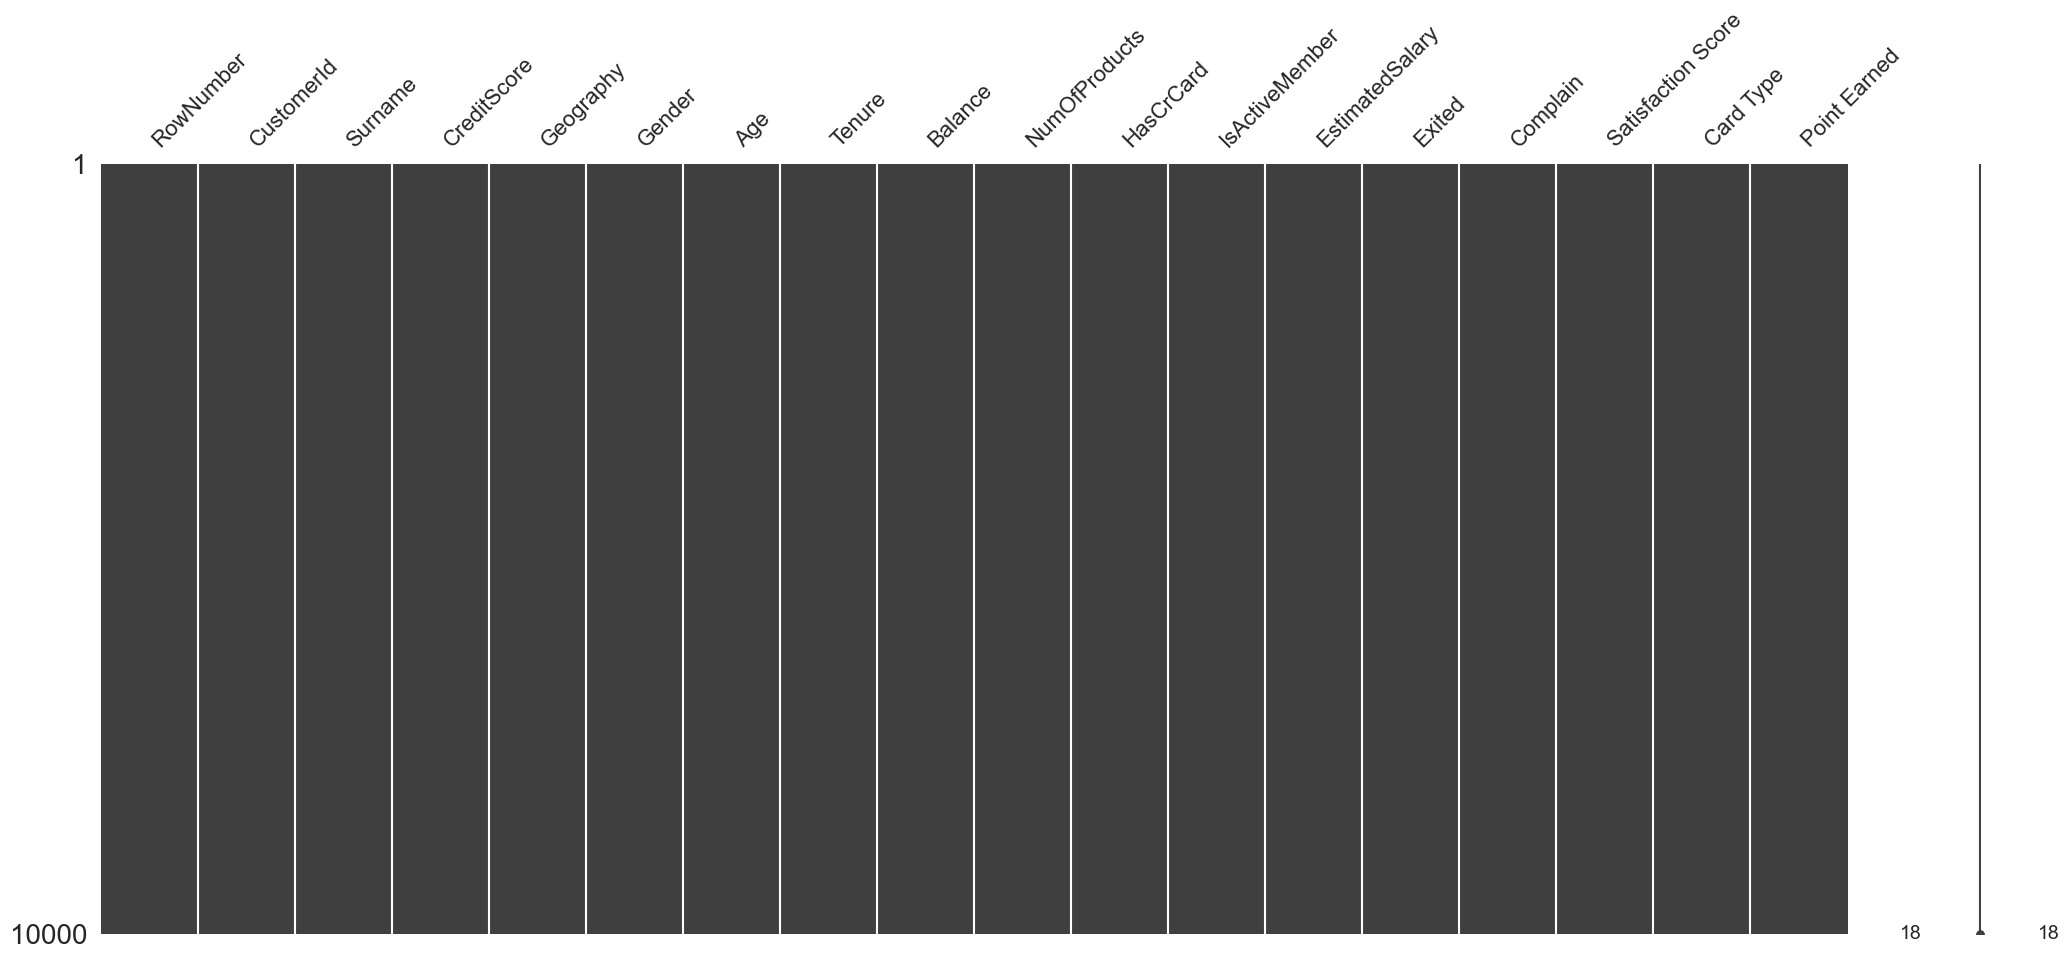

In [34]:
import missingno as mn
mn.matrix(data_set)

Identifying Numeric and Categorical Columns

In [35]:
# Numerical dataframe
num_col = data_set.select_dtypes(include=["int64", "float64"])

# Categorical dataframe
cat_col = data_set.select_dtypes(include=["object"])

print("Numeric Columns are")
print(num_col.columns)

print("\nCategorical Columns are")
print(cat_col.columns)

Numeric Columns are
Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Point Earned'],
      dtype='str')

Categorical Columns are
Index(['Surname', 'Geography', 'Gender', 'Card Type'], dtype='str')


##### Checking  for outliers

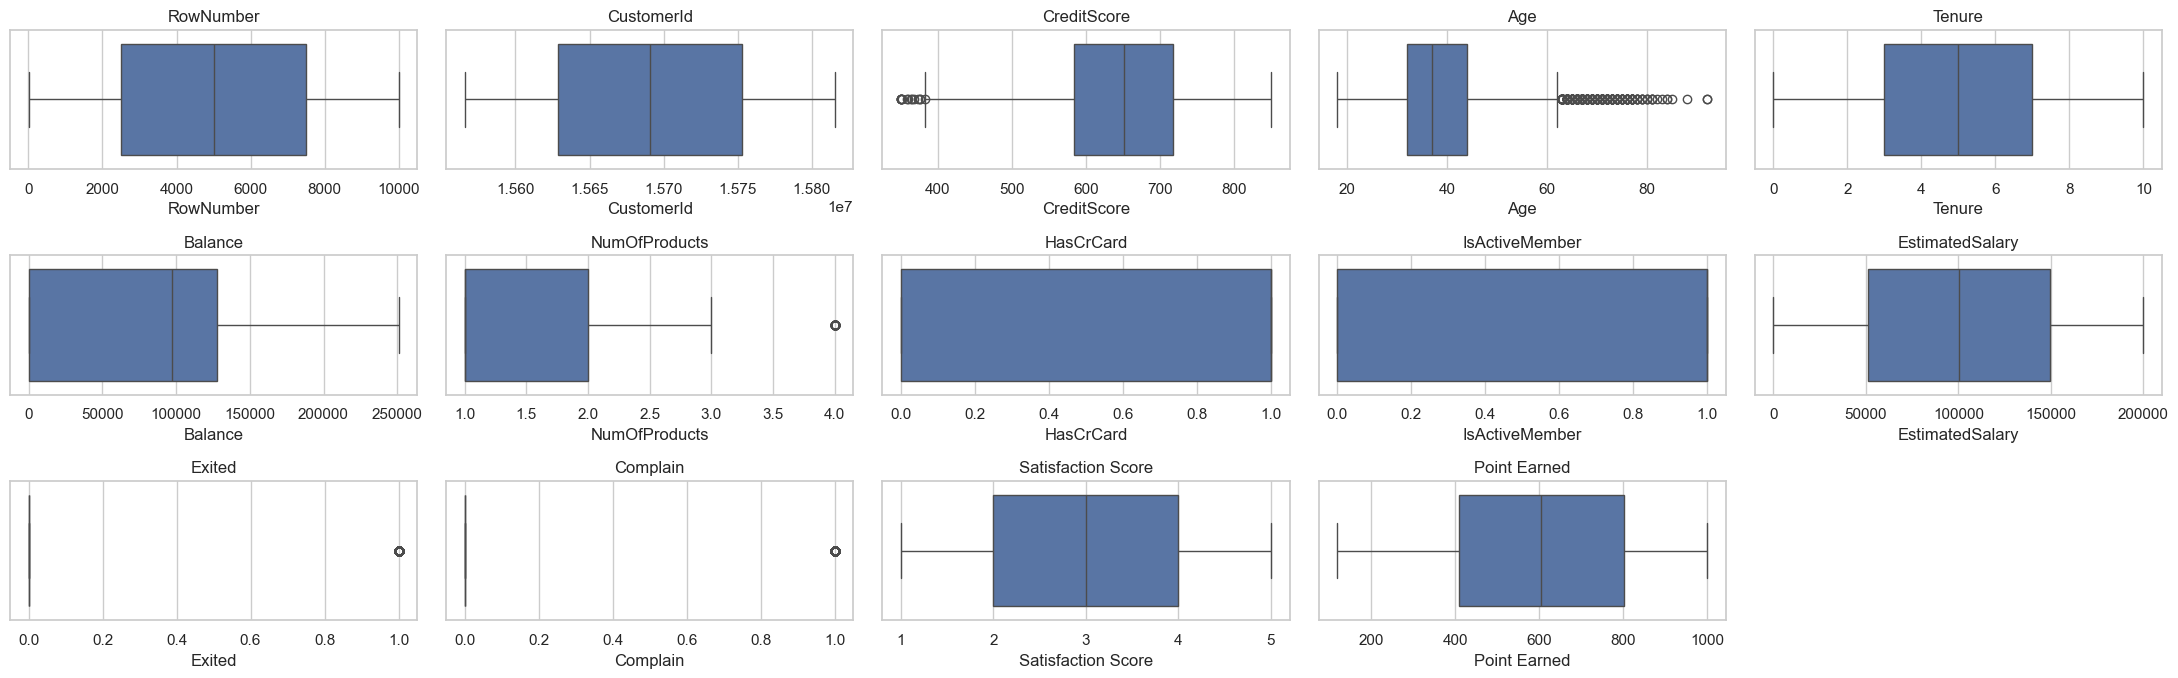

In [36]:
fig = plt.figure(figsize=(22,20))
# Looping through all numerical columns
for i in range(len(num_col.columns)):
    ax=fig.add_subplot(9, 5, i+1) # Create subplots arranged in 9 rows and 5 columns
    sns.boxplot(x=num_col.iloc[:, i],ax=ax) # Draw a boxplot for each numerical feature
    ax.set_title(num_col.columns[i])
plt.tight_layout() # Adjust spacing between plots to prevent overlapping
plt.show()

A visual exploration of the categorical columns using bar charts

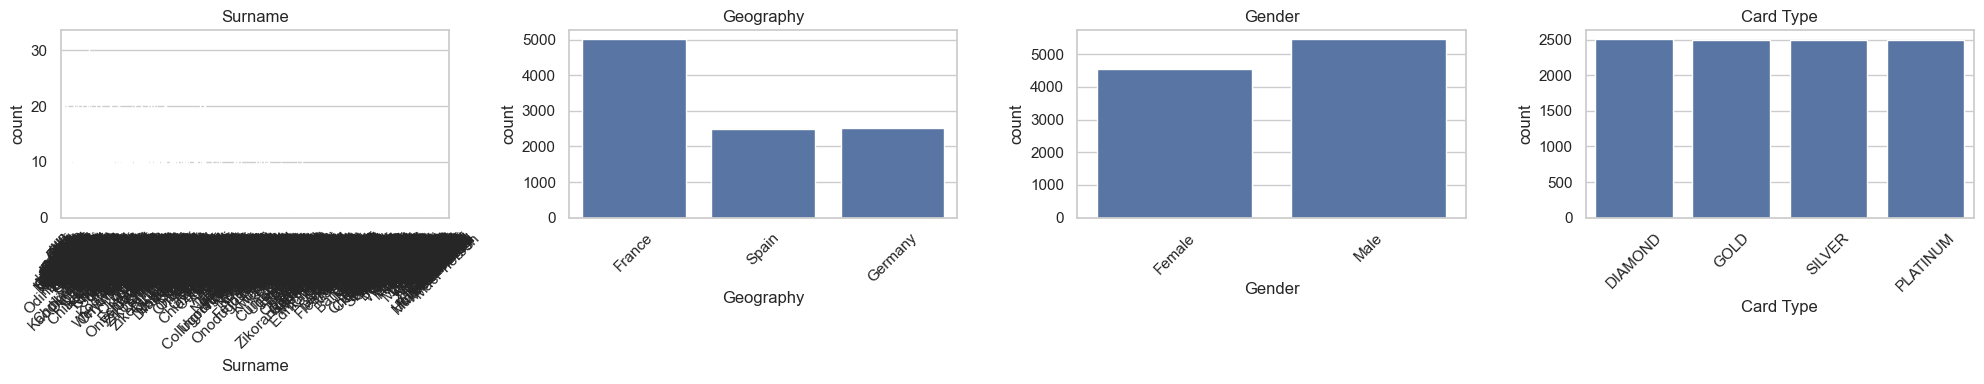

In [37]:
n_cols = len(cat_col.columns)

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 4))

for i, col in enumerate(cat_col.columns):
    sns.countplot(x=data_set[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Distribution of the numeric features

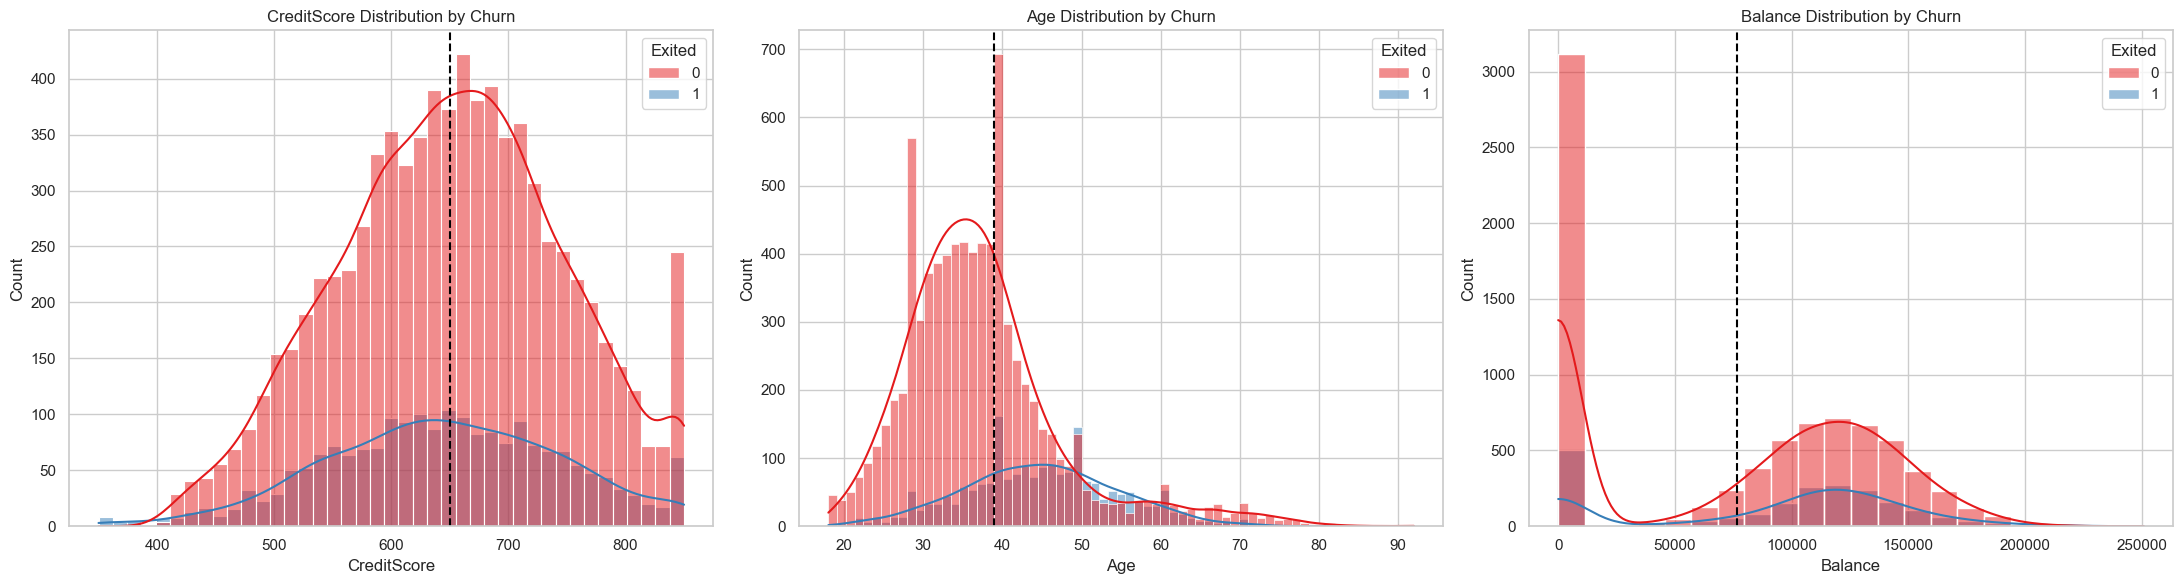

In [ ]:

sns.set(style="whitegrid")

# Create a figure with 1 row and 3 columns of subplots

fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# List of numerical features to visualize
features = ['CreditScore', 'Age', 'Balance']

# Loop through each feature and create a histogram
for i, col in enumerate(features):
    
    # Histogram plot with KDE (Kernel Density Estimate) to helps visualize: Distribution of values, Frequency of observations
    #Differences between churned and non-churned customers
    sns.histplot(
        data=data_set,
        x=col,              # Feature being plotted
        hue='Exited',       # Split distributions by churn status
        kde=True,           # Add smooth density curve
        ax=ax[i],           # Position subplot
        palette='Set1'      # Color theme
    )
    
    # Add a vertical dashed line representing the mean value of the current feature
    ax[i].axvline(
        data_set[col].mean(),
        color='black',
        linestyle='--'
    )
    
    # Set title for each subplot
    ax[i].set_title(f"{col} Distribution by Churn")


plt.tight_layout()

# Display all plots
plt.show()

1. In the Credit score Distribution,  majority of customers have moderate creditworthiness, while only a small percentage have  poor creditworthiness. 

2. In balance distribution,a good number of customers have no account balance, while others maintain moderate to high balances.

3. Most customers are between 30 and 45 years old and few older customers above 60

The KDE curve shows the density distribution while the mean line highlights average values.

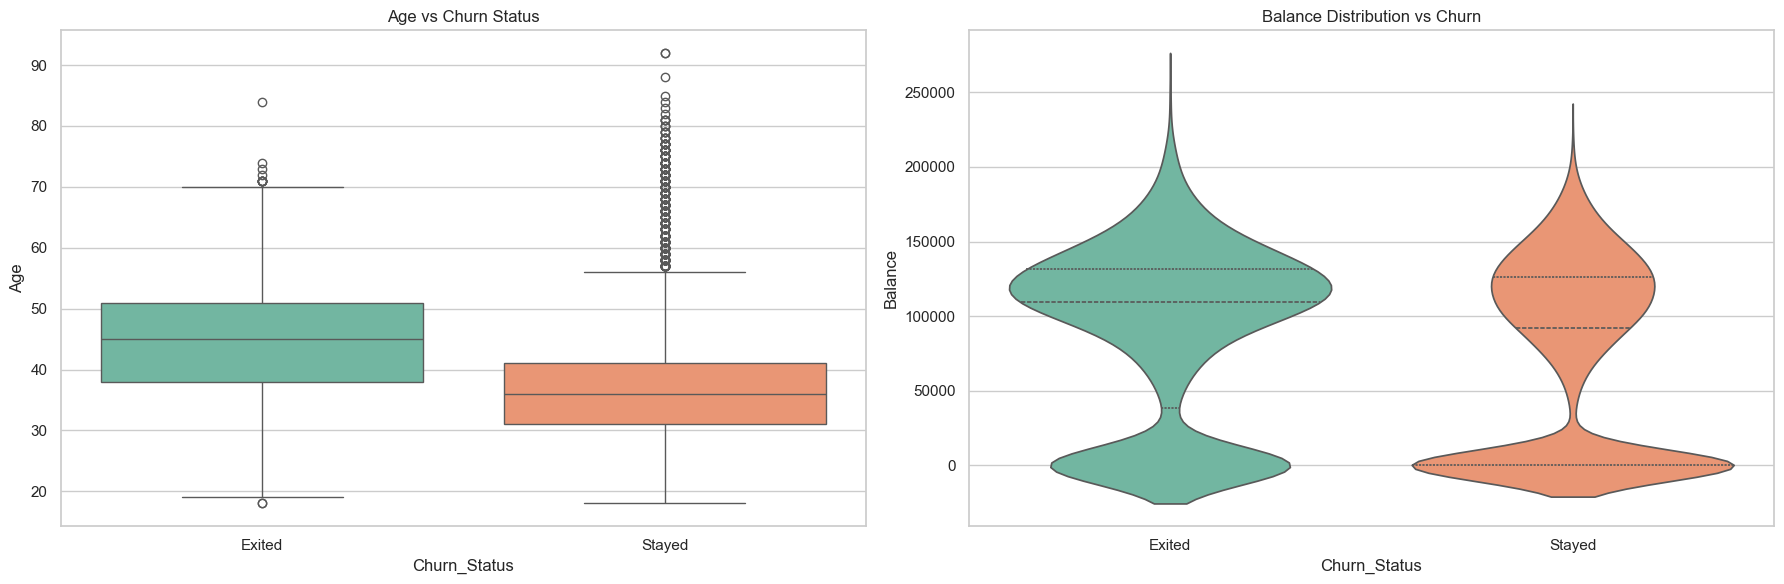

In [ ]:
# Create a new column called 'Churn_Status'
# This converts the numerical values in the 'Exited' column

data_set['Churn_Status'] = data_set['Exited'].map({0: 'Stayed', 1: 'Exited'})

# Create a figure with 1 row and 2 columns of plots
# figsize controls the overall size of the plots
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot: Age vs Churn Status

# This allows us to compare age distributions between customers who stayed and those who exited.
sns.boxplot(
    data=data_set,
    x='Churn_Status',   
    y='Age',            
    palette='Set2',     
    ax=ax[0]           
)

ax[0].set_title("Age vs Churn Status")

# Violin Plot: Balance vs Churn

# A violin plot showing Distribution shape, Density of values and Quartiles inside the distribution
# It helps understand how customer balances differ between churned and retained customers.
sns.violinplot(
    data=data_set,
    x='Churn_Status',   
    y='Balance',        
    inner='quartile',   # Show quartile lines inside violin
    palette='Set2',
    ax=ax[1]            # Second subplot
)


ax[1].set_title("Balance Distribution vs Churn")

# Adjust spacing between plots for better appearance
plt.tight_layout()


plt.show()

1. In the Age vs Exited box plot Older customers appear more likely to churn compared to younger customers therefore, Age is likely an important predictive feature in the churn model.

2. In Balance Vs Exited Violin Plot, customers who exited tend to have higher balances and those who stayed may contain many zero-balance accounts.

In [40]:
data_set.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned', 'Churn_Status'],
      dtype='str')

In [41]:
model_df = data_set.drop([
    'RowNumber',
    'CustomerId',
    'Surname',
    'Complain',
    'Churn_Status'
], axis=1)

In [42]:
model_df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='str')

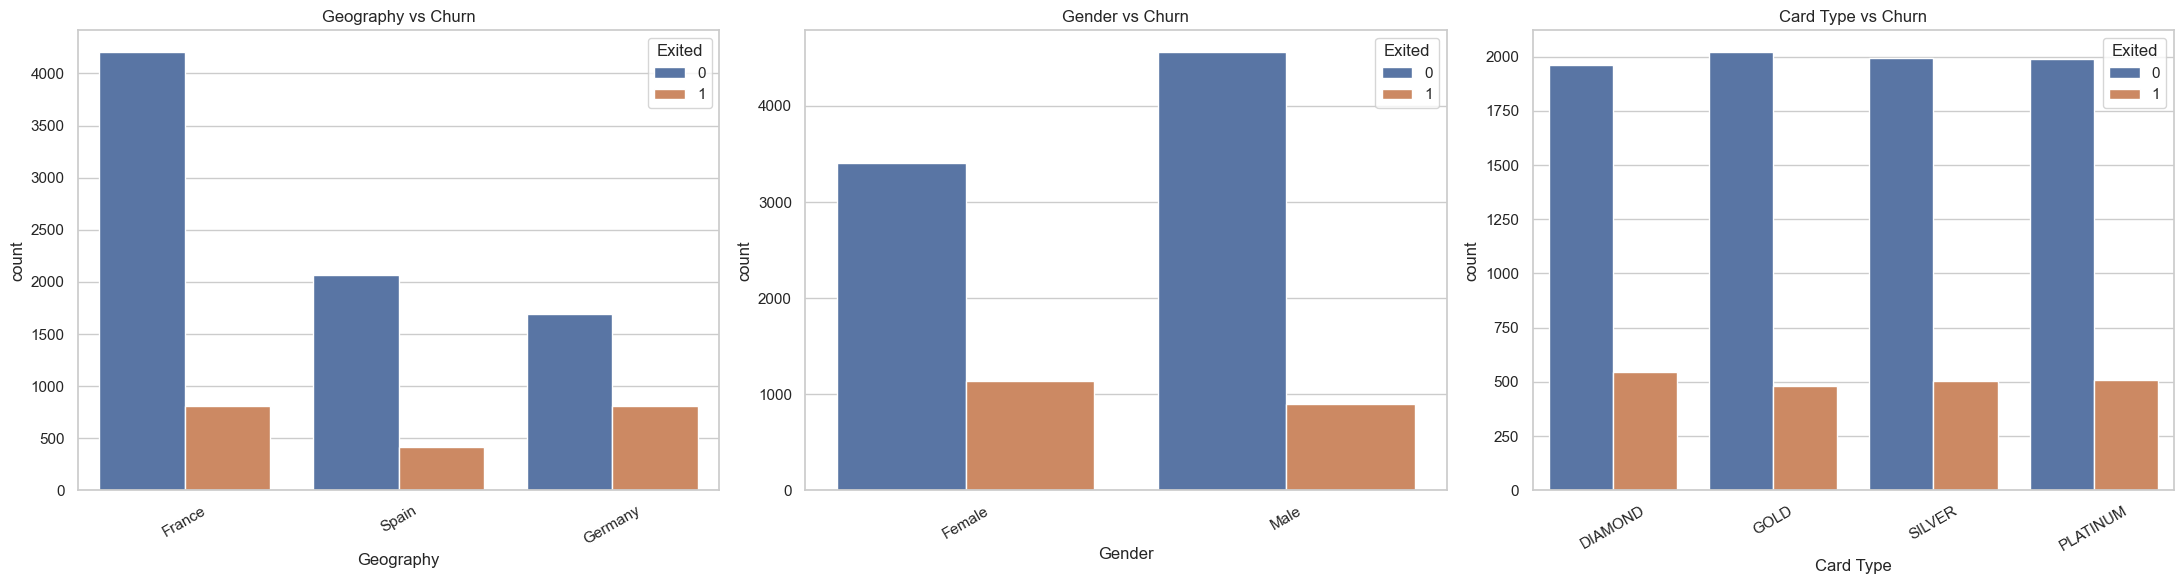

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

features = ['Geography', 'Gender', 'Card Type']

for i, col in enumerate(features):
    sns.countplot(data=model_df, x=col, hue='Exited', ax=ax[i])
    ax[i].set_title(f"{col} vs Churn")
    ax[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Checking for Linear separability

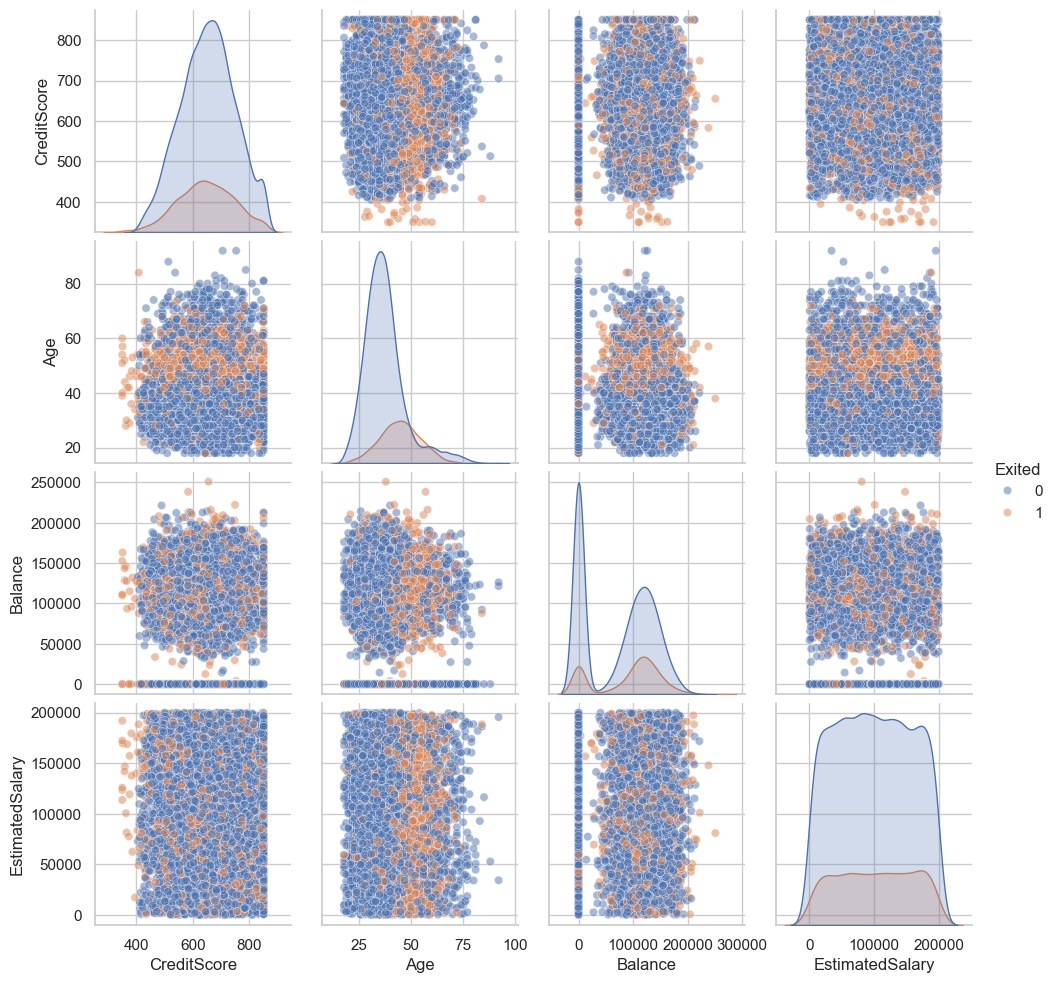

In [ ]:
# Import seaborn library for data visualization
import seaborn as sns

# Select important numerical features for visualization that influence customer churn
selected_features = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary'
]

# Create a pairplot to visualize relationships
# between multiple numerical variables
sns.pairplot(
    
    # Include selected features together with the target variable
    model_df[selected_features + ['Exited']],
    
    # Different colors are used for churn classes
    # 0 = Stayed, 1 = Exited
    hue='Exited',
    
    # KDE  is used on diagonal plots to show smooth distributions of each variable
    diag_kind='kde',
    
    # Reduce opacity to improve visibility where points overlap
    plot_kws={'alpha': 0.5}
)


plt.show()

#### Checking for Class Imbalancement

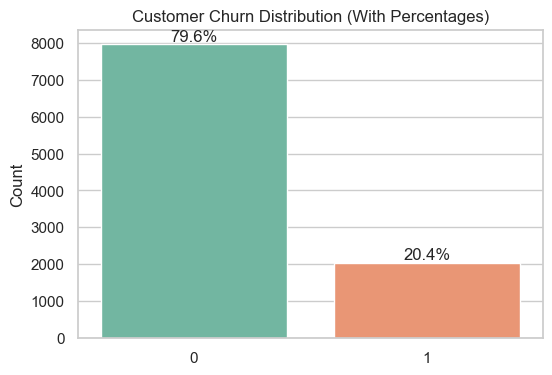

In [ ]:

plt.figure(figsize=(6,4))

# Create a countplot to show the number of customers
# in each churn category
# Exited:
# 0 = Customer Stayed
# 1 = Customer Churned/Exited
ax = sns.countplot(
    x='Exited',
    data=model_df,
    palette='Set2'
)

# Calculate the total number of observations
# This is used to compute percentages
total = len(model_df)

# Loop through each bar in the countplot
for p in ax.patches:
    
    # Calculate percentage for each class
    percentage = f'{100 * p.get_height() / total:.1f}%'
    
    # Add percentage labels above each bar
    ax.annotate(
        percentage,
        
        # Position annotation at the center top of each bar
        (p.get_x() + p.get_width()/2, p.get_height()),
        
        # Horizontal alignment
        ha='center',
        
        # Vertical alignment
        va='bottom'
    )

# Add title to the plot
plt.title("Customer Churn Distribution (With Percentages)")

# Remove x-axis label
plt.xlabel("")

# Set y-axis label
plt.ylabel("Count")

# Display the plot
plt.show()

## 4. Preparing Data for Modelling

#### Separating features and the target

In [ ]:

X = model_df.drop('Exited', axis=1)
y = model_df['Exited']

print(X.shape)
print(y.shape)

(10000, 13)
(10000,)


### Encoding

In [ ]:
# Perform One-Hot Encoding on categorical variables
# pd.get_dummies() converts categorical text values into numerical binary columns (0 and 1)
   # drop_first=True removes one category from each feature
    # to avoid multicollinearity (dummy variable trap)

X = pd.get_dummies( X,drop_first=True)


X.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,3,377,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,5,350,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,5,425,False,True,False,True,False,False


#### Train test split

In [ ]:
# Split the dataset into training and testing sets


X_train, X_test, y_train, y_test = train_test_split(X,y,                 

    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)


Training Shape: (8000, 16)
Testing Shape: (2000, 16)


#### Feature scaling

In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Modelling

In [51]:
# Initialize models
lr_model = LogisticRegression()
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}


In [52]:
# Train and evaluate models
results = []

for name, model in models.items():

    # Logistic Regression uses scaled data
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
        probabilities = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='ROC AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Gradient Boosting,0.872,0.787879,0.509804,0.619048,0.876764
1,Random Forest,0.868,0.795082,0.475490,0.595092,0.864950
0,Logistic Regression,0.813,0.623188,0.210784,0.315018,0.778356


In [53]:
# Import classification report
from sklearn.metrics import classification_report

# Generate classification reports for all models
for name, model in models.items():

    # Logistic Regression uses scaled data
    if name == "Logistic Regression":
        predictions = model.predict(X_test_scaled)

    else:
        predictions = model.predict(X_test)

    # Print model name
    print(f"\n{name} Classification Report")
    print("-" * 50)

    # Print classification report
    print(classification_report(y_test, predictions))


Logistic Regression Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000


Random Forest Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1592
           1       0.80      0.48      0.60       408

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000


Gradient Boosting Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0     

Gradient Boosting was selected as the final model because it achieved the best overall balance between precision and recall, with the highest F1-score and recall for predicting defaulters/churners. This makes it the most effective model for identifying high-risk customers while maintaining strong overall accuracy.

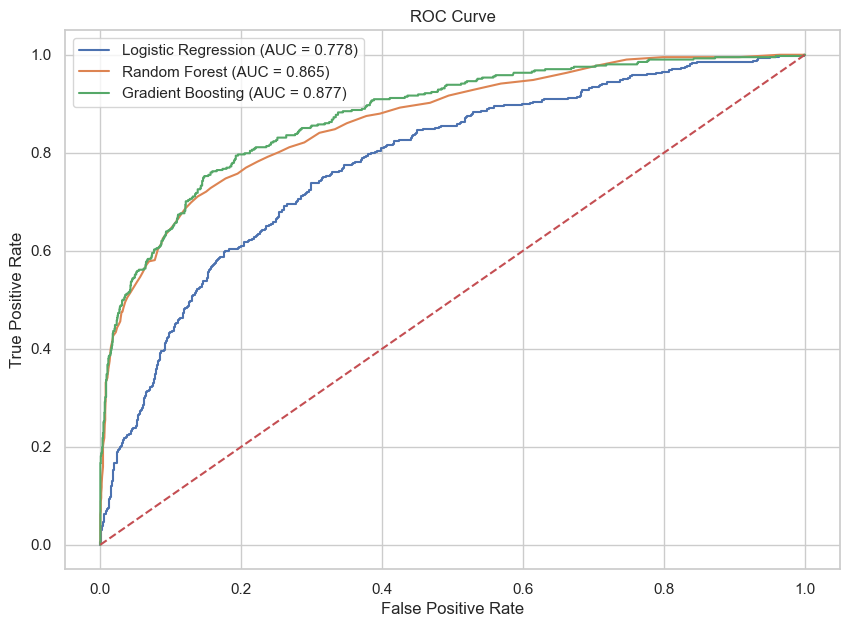

In [54]:
# Plot ROC curves
plt.figure(figsize=(10,7))

for name, model in models.items():

    if name == "Logistic Regression":
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

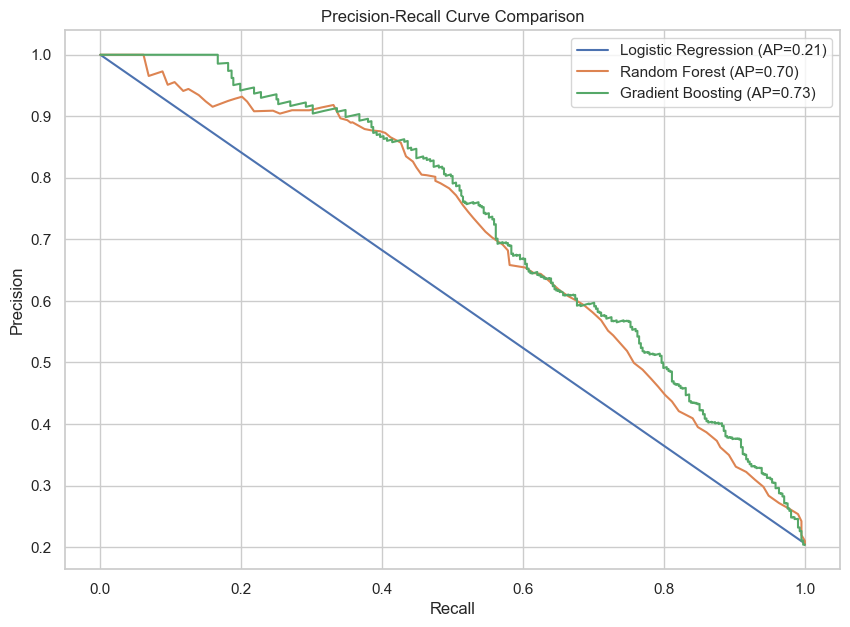

In [55]:
# Set figure size for better visibility of the Precision-Recall curves
plt.figure(figsize=(10,7))

# Dictionary of trained models for easy looping and comparison
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

# Loop through each model to compute Precision-Recall curve
for name, model in models.items():
    
    # Get predicted probabilities for the positive class (churn = 1)
    probs = model.predict_proba(X_test)[:, 1]
    
    # Compute precision-recall pairs at different probability thresholds
    precision, recall, _ = precision_recall_curve(y_test, probs)
    
    # Compute Average Precision Score (summary metric of PR curve)
    ap = average_precision_score(y_test, probs)

    # Plot Precision-Recall curve for each model
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

# Label x-axis as Recall
plt.xlabel("Recall")

# Label y-axis as Precision
plt.ylabel("Precision")

# Add title to the plot
plt.title("Precision-Recall Curve Comparison")

# Show legend to identify models
plt.legend()

# Display the plot
plt.show()

### 6. Hyperparameter Tuning
 This is where we get to optimize our best performing model.

#### Gradient Boosting Tuning

In [56]:
# Import required libraries
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Initialize the Gradient Boosting model
gb = GradientBoostingClassifier(
    random_state=20
)

# Define hyperparameter distribution (not fixed grid anymore)
gb_params = {
    'n_estimators': randint(100, 201),        # Random values between 100–200
    'learning_rate': uniform(0.01, 0.1),       # Continuous range starting at 0.01
    'max_depth': randint(2, 5),                # 2 to 4
    'min_samples_split': randint(2, 11),      # 2 to 10
    'min_samples_leaf': randint(1, 5),        # 1 to 4
    'subsample': uniform(0.8, 0.2)            # 0.8 to 1.0
}

# Perform Randomized Search with Cross Validation
gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=30,            # Number of random combinations to try (you can increase for better results)
    cv=5,                 # 5-Fold Cross Validation
    scoring='f1',        # Optimize using F1-score
    n_jobs=-1,           # Use all CPU cores
    verbose=1,
    random_state=20
)

# Train the model using Randomized Search
gb_random.fit(X_train, y_train.values.ravel())

# Display best hyperparameters
print("Best Gradient Boosting Parameters:")
print(gb_random.best_params_)

# Display best Cross-Validated F1 Score
print("\nBest Cross-Validated F1 Score:")
print(gb_random.best_score_)

# Save the best tuned model
best_gb_model = gb_random.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Gradient Boosting Parameters:
{'learning_rate': np.float64(0.05587560622796756), 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 184, 'subsample': np.float64(0.9379767274783033)}

Best Cross-Validated F1 Score:
0.590002547805979


In [57]:
# Retrieve the best Gradient Boosting model from Randomized Search
best_gb_model = gb_random.best_estimator_

# Train the best model on the full training dataset
best_gb_model.fit(X_train, y_train.values.ravel())

# Make predictions on the test dataset
y_pred = best_gb_model.predict(X_test)

# Import classification report
from sklearn.metrics import classification_report

# Display the classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Non-Defaulter', 'Defaulter']
    )
)

               precision    recall  f1-score   support

Non-Defaulter       0.88      0.96      0.92      1592
    Defaulter       0.78      0.50      0.61       408

     accuracy                           0.87      2000
    macro avg       0.83      0.73      0.77      2000
 weighted avg       0.86      0.87      0.86      2000



Hyperparameter tuning improves model performance by optimizing internal model settings.
We used GridSearchCV with F1-score because churn prediction is an imbalanced classification problem.

#### Save the best performing model


In [58]:
import pickle

# Save the best trained Gradient Boosting model
with open('Customer_churn_model.pkl', 'wb') as file:
    pickle.dump(best_gb_model, file)

## 7. Error Anaysis

1. Confusion Matrix

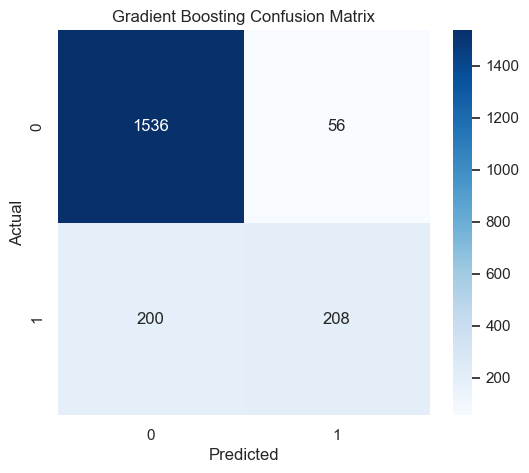

In [59]:
# Confusion matrix for Gradient Boosting

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Gradient Boosting model
gb_model.fit(X_train, y_train.values.ravel())

# Make predictions
gb_pred = gb_model.predict(X_test)

# Create confusion matrix using correct predictions
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

2. Create a DataFrame Showing Actual vs Predicted Results

This helps identify which observations were classified wrongly.

In [60]:
# Create dataframe for error analysis

error_analysis = X_test.copy()

# Add actual and predicted values
error_analysis['Actual'] = y_test.values
error_analysis['Predicted'] = gb_pred

# Identify whether prediction was correct
error_analysis['Correct_Prediction'] = (
    error_analysis['Actual'] == error_analysis['Predicted']
)

# Display first rows
error_analysis.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Actual,Predicted,Correct_Prediction
6176,608,38,8,103653.51,2,1,1,137079.86,3,843,True,False,False,False,False,True,0,0,True
7072,686,37,9,134560.62,1,1,0,27596.39,1,617,False,False,True,False,False,False,0,0,True
877,652,42,4,0.00,2,1,1,38152.01,5,230,False,True,False,True,False,False,0,0,True
6539,697,45,1,0.00,2,1,0,46807.62,3,559,False,False,False,False,True,False,1,0,False
5190,735,36,5,0.00,2,1,0,105152.17,3,259,False,True,True,False,True,False,0,0,True


3. Extract Misclassified Records

This filters only the wrongly predicted observations.

In [61]:
# Misclassified observations only

misclassified = error_analysis[
    error_analysis['Correct_Prediction'] == False
]

print("Number of Misclassified Records:", len(misclassified))

misclassified.head()

Number of Misclassified Records: 256


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Actual,Predicted,Correct_Prediction
6539,697,45,1,0.00,2,1,0,46807.62,3,559,False,False,False,False,True,False,1,0,False
2560,650,30,6,0.00,1,0,0,67997.13,4,963,False,True,False,True,False,False,1,0,False
6532,756,67,4,0.00,3,1,1,93081.87,1,593,False,False,True,True,False,False,0,1,False
3317,779,71,3,0.00,2,1,1,146895.36,1,858,False,False,True,False,True,False,1,0,False
8708,778,48,3,102290.56,2,1,0,182691.31,1,434,True,False,False,False,True,False,0,1,False


4. Check Types of Errors

This identifies:

* False Positives
* False Negatives


In [62]:
# False Positives
# Model predicted customer will exit but actually stayed

false_positive = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]

# False Negatives
# Model predicted customer stayed but actually exited

false_negative = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

False Positives: 56
False Negatives: 200


5. Compare Feature Patterns in Errors

This helps identify what characteristics are common among wrong predictions.

Numerical Features Analysis

In [63]:
# Compare averages of numerical features

misclassified.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Actual,Predicted
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000
mean,652.800781,41.988281,4.968750,90766.147109,1.289062,0.750000,0.378906,101237.597500,3.011719,616.601562,0.781250,0.218750
std,92.465761,9.256469,2.958371,61911.148473,0.518706,0.433861,0.486065,56860.756237,1.472579,214.229265,0.414208,0.414208
min,407.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,468.940000,1.000000,220.000000,0.000000,0.000000
25%,590.500000,36.000000,2.000000,0.000000,1.000000,0.750000,0.000000,53809.580000,2.000000,417.250000,1.000000,0.000000
50%,652.500000,42.000000,5.000000,112928.240000,1.000000,1.000000,0.000000,99144.400000,3.000000,652.000000,1.000000,0.000000
75%,713.250000,47.000000,8.000000,135708.540000,2.000000,1.000000,1.000000,153282.282500,4.000000,799.250000,1.000000,0.000000
max,850.000000,71.000000,10.000000,210433.080000,3.000000,1.000000,1.000000,199378.580000,5.000000,995.000000,1.000000,1.000000


In [64]:
# Correct predictions

correct_predictions = error_analysis[
    error_analysis['Correct_Prediction'] == True
]

# Compare means

print("Correct Predictions Mean")
print(correct_predictions.mean(numeric_only=True))

print("\nMisclassified Mean")
print(misclassified.mean(numeric_only=True))

Correct Predictions Mean
CreditScore              649.645069
Age                       38.446101
Tenure                     5.037844
Balance                74578.762391
NumOfProducts              1.565367
HasCrCard                  0.689794
IsActiveMember             0.528096
EstimatedSalary       102539.885705
Satisfaction Score         3.026950
Point Earned             606.938073
Geography_Germany          0.236812
Geography_Spain            0.248853
Gender_Male                0.543578
Card Type_GOLD             0.233945
Card Type_PLATINUM         0.248280
Card Type_SILVER           0.256307
Actual                     0.119266
Predicted                  0.119266
Correct_Prediction         1.000000
dtype: float64

Misclassified Mean
CreditScore              652.800781
Age                       41.988281
Tenure                     4.968750
Balance                90766.147109
NumOfProducts              1.289062
HasCrCard                  0.750000
IsActiveMember             0.378906
Esti

comparing  against the correctly classified records:

In [65]:
# Correct predictions

correct_predictions = error_analysis[
    error_analysis['Correct_Prediction'] == True
]

# Compare means

print("Correct Predictions Mean")
print(correct_predictions.mean(numeric_only=True))

print("\nMisclassified Mean")
print(misclassified.mean(numeric_only=True))

Correct Predictions Mean
CreditScore              649.645069
Age                       38.446101
Tenure                     5.037844
Balance                74578.762391
NumOfProducts              1.565367
HasCrCard                  0.689794
IsActiveMember             0.528096
EstimatedSalary       102539.885705
Satisfaction Score         3.026950
Point Earned             606.938073
Geography_Germany          0.236812
Geography_Spain            0.248853
Gender_Male                0.543578
Card Type_GOLD             0.233945
Card Type_PLATINUM         0.248280
Card Type_SILVER           0.256307
Actual                     0.119266
Predicted                  0.119266
Correct_Prediction         1.000000
dtype: float64

Misclassified Mean
CreditScore              652.800781
Age                       41.988281
Tenure                     4.968750
Balance                90766.147109
NumOfProducts              1.289062
HasCrCard                  0.750000
IsActiveMember             0.378906
Esti

6. Visualize Error Patterns

Example using Age.

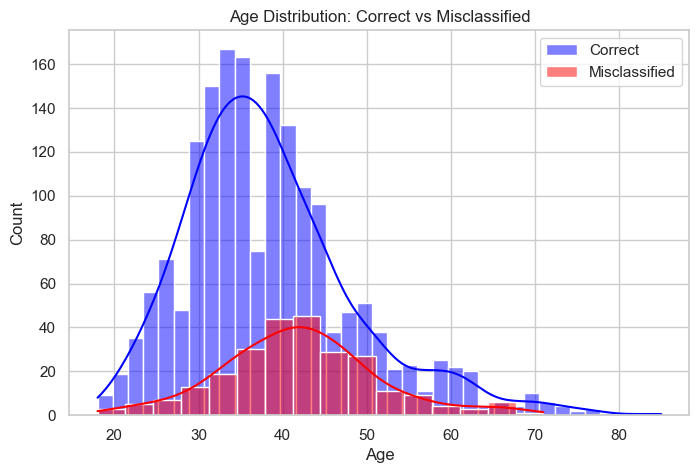

In [66]:
# Compare Age distribution

plt.figure(figsize=(8,5))

sns.histplot(
    correct_predictions['Age'],
    color='blue',
    label='Correct',
    kde=True
)

sns.histplot(
    misclassified['Age'],
    color='red',
    label='Misclassified',
    kde=True
)

plt.title("Age Distribution: Correct vs Misclassified")
plt.legend()
plt.show()

## 8. Feature Importance Analysis

This helps identify which variables influence predictions most.

In [67]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Age,0.386801
4,NumOfProducts,0.300325
6,IsActiveMember,0.107082
3,Balance,0.085989
10,Geography_Germany,0.053179
0,CreditScore,0.019252
7,EstimatedSalary,0.018839
12,Gender_Male,0.014789
9,Point Earned,0.006975
2,Tenure,0.002684


### 7. Plot Feature Importance

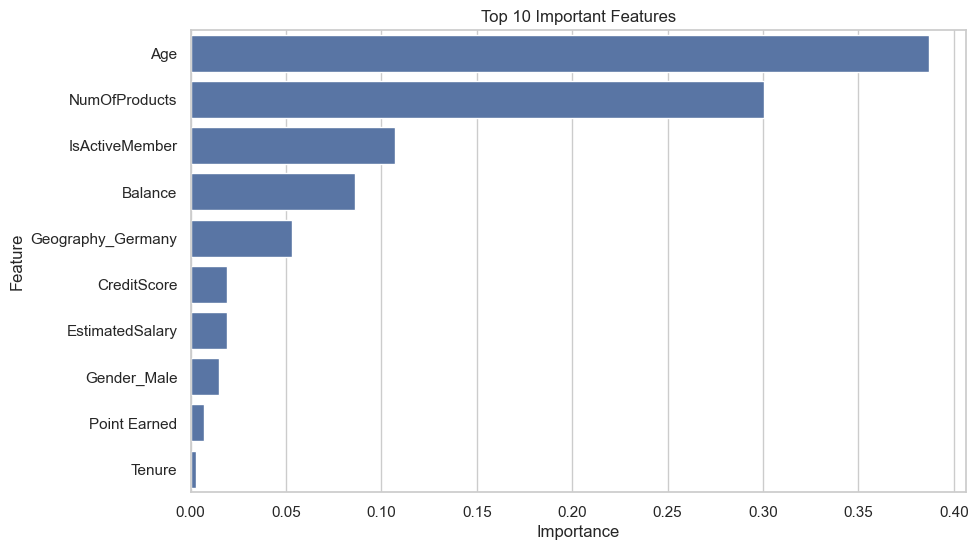

In [68]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
# This ensures new user inputs are transformed the same way as training data.
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)




## Overall Model Interpretation
The machine learning models were developed to predict customer churn behavior. Multiple algorithms were trained and evaluated, including:
- Logistic Regression
- Random Forest
- Gradient Boosting

The models were assessed using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Curve
- Confusion Matrix

Among the models tested, Gradient Boosting achieved the best overall performance and was therefore selected as the final model.



# Error Analysis Interpretation

The error analysis focused on identifying misclassified observations and understanding where the model struggles.

The analysis revealed:
- Some customers had characteristics that overlapped between churners and non-churners.
- False Negatives indicate customers who actually churned but were predicted as retained.
- False Positives indicate customers predicted to churn but who actually stayed.

These errors may occur because some customer behaviors are very similar across both classes.



# Feature Importance Interpretation

The feature importance analysis showed that variables such as:
- Age
- Balance
- Credit Score
- Estimated Salary

played a major role in prediction decisions.

This indicates that customer financial behavior and demographic characteristics strongly influence churn probability.



# Suggestions and Recommendations

## Business Recommendations
1. Customers with high balances and older age groups should be monitored more closely for churn risk.
2. The company should design targeted retention campaigns for high-risk customers.
3. Personalized customer engagement strategies can reduce customer exits.



# Final Conclusion

The project successfully developed a machine learning model capable of predicting customer churn with high performance.

The model can assist businesses in:
- Identifying high-risk customers.
- Improving retention strategies.
- Reducing revenue loss due to customer churn.


